In [ ]:
import torch
from paddy_data_loader import load_train_val_test_data
from shufflenet_v2 import ShuffleNetV2


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import timm
from sklearn.metrics import confusion_matrix

import helper_utils

## Load config, data and model

In [4]:
# config and device
device =  helper_utils.get_device()
configs = helper_utils.load_config("../configs/config.yaml")
models = configs.models
dataset = configs.dataset

In [12]:
train_loader, val_loader, test_loader = load_train_val_test_data(batch_size=64)

In [16]:
densenet_201_teacher = timm.create_model(models.teacher_timm_name, pretrained=False, num_classes=dataset.num_classes)
densenet_201_teacher.load_state_dict(torch.load(f"../{models.teacher_model_dir}"))
densenet_201_teacher.to(device)
densenet_201_teacher.eval()

shuffleNetV2_05x_student = ShuffleNetV2(n_class=dataset.num_classes, model_size=models.student_model_size)
#shuffleNetV2_05x_student.load_state_dict(torch.load(f"../{models.student_model_dir}"))
#shuffleNetV2_05x_student.to(device)
#shuffleNetV2_05x_student.eval()

## Confusion Marix and Accuracy for each class

In [17]:
# class name dataset
class_names = train_loader.dataset.classes

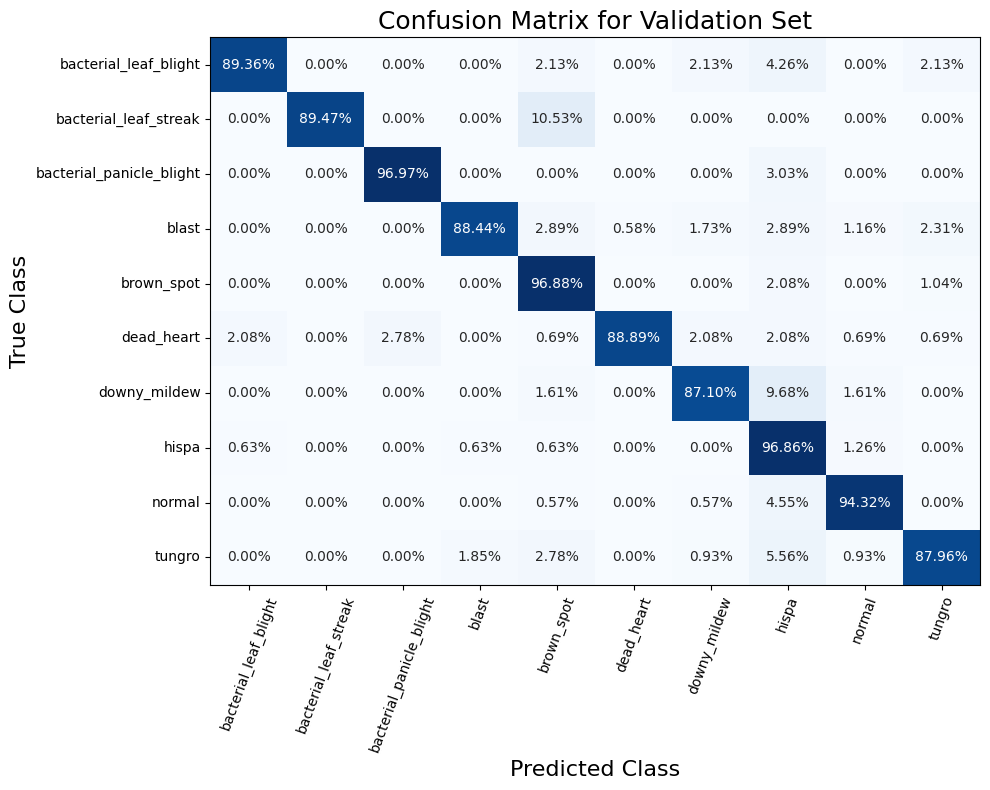

In [ ]:
true_labels = []
predicted_labels = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = densenet_201_teacher(images) # change the model as needed
        _, predicted = torch.max(outputs.data, 1)
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())
# compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix for Validation Set")
plt.xticks(rotation=70)
# ADD THE the border around the confusion matrix
plt.gca().spines["top"].set_visible(True)
plt.gca().spines["right"].set_visible(True)
plt.gca().spines["left"].set_visible(True)
plt.gca().spines["bottom"].set_visible(True)


# there is no need to add heat map color bar legend for the confusion matrix since the values are already annotated in percentage on the heatmap. So we can remove the color bar legend to make the plot cleaner.
plt.gca().collections[0].colorbar.remove()

# add grid lines to the confusion matrix
# set font title size to 18 and the label size to 16
plt.title("Confusion Matrix for Validation Set", fontsize=18)
plt.xlabel("Predicted Class", fontsize=16)
plt.ylabel("True Class", fontsize=16)
# tight layout and save the figure as png with high resolution (300 dpi)
#plt.tight_layout()
#plt.savefig("confusion_matrix.png", dpi=300)


plt.show()